# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

## 🖼️ Visualize Sample Images

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'), # Yeh nayi layer humne jodi hai
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=1,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.2760 - loss: 1.9803 - val_accuracy: 0.3434 - val_loss: 1.8225
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.3271 - loss: 1.8457 - val_accuracy: 0.3692 - val_loss: 1.7807
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3537 - loss: 1.7848 - val_accuracy: 0.3894 - val_loss: 1.7211
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.3628 - loss: 1.7528 - val_accuracy: 0.3936 - val_loss: 1.7136
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3764 - loss: 1.7248 - val_accuracy: 0.4044 - val_loss: 1.6762
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.3812 - loss: 1.7012 - val_accuracy: 0.4204 - val_loss: 1.6294
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3927 - loss: 1.6756 - val_accuracy: 0.4162 - val_loss: 1.6458
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.3993 - loss: 1.6586 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4500 - loss: 1.5686
ANN Test Accuracy: 0.44999998807907104


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights =True)

print("Training CNN with Early Stoppiang...")
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=1,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Training CNN with Early Stoppiang...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 237s 329ms/step - accuracy: 0.4426 - loss: 1.5640 - val_accuracy: 0.4106 - val_loss: 1.7327
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 236s 335ms/step - accuracy: 0.5931 - loss: 1.1582 - val_accuracy: 0.6458 - val_loss: 1.0224
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 232s 329ms/step - accuracy: 0.6711 - loss: 0.9477 - val_accuracy: 0.5704 - val_loss: 1.2858
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 262s 329ms/step - accuracy: 0.7208 - loss: 0.8134 - val_accuracy: 0.6588 - val_loss: 1.0131
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 228s 324ms/step - accuracy: 0.7561 - loss: 0.6999 - val_accuracy: 0.6522 - val_loss: 1.0289
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 264s 327ms/step - accuracy: 0.7908 - loss: 0.6035 - val_accuracy: 0.6866 - val_loss: 1.0203
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 229s 326ms/step - accuracy: 0.8166 - loss: 0.5264 - val_accuracy: 0.7318 - val_loss: 0.8087
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.6884 - loss: 0.9530
CNN Test Accuracy: 0.6883999705314636


## 📈 Compare Learning Curves

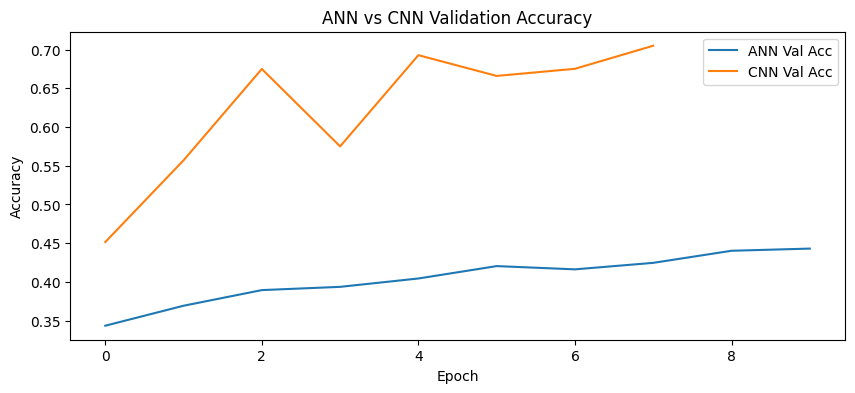

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])


aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])


aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


aug_early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)


print("Training Augmented CNN...")
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=1,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop]
)

Training Augmented CNN...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 95ms/step - accuracy: 0.3721 - loss: 1.7223 - val_accuracy: 0.4788 - val_loss: 1.4283
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.4682 - loss: 1.4769 - val_accuracy: 0.5386 - val_loss: 1.2881
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5066 - loss: 1.3861 - val_accuracy: 0.5464 - val_loss: 1.2734
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.5291 - loss: 1.3210 - val_accuracy: 0.6000 - val_loss: 1.1378
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.5473 - loss: 1.2724 - val_accuracy: 0.5782 - val_loss: 1.1635
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.5587 - loss: 1.2471 - val_accuracy: 0.5982 - val_loss: 1.1349
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.5663 - loss: 1.2245 - val_accuracy: 0.6212 - val_loss: 1.0604
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4500
1,CNN,0.6884


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**